In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_PATH = "/Users/dhairyabhatt/code_dir/Data analytics projects/world_health/data"
OUTPUT_PATH = os.path.join(BASE_PATH, "phase3_outputs")

In [3]:
q28 = pd.read_csv(f"{BASE_PATH}/phase3_outputs/q28_ntd_quartile.csv")

print(q28.dtypes)
print(q28["burden_q"].unique())
print(q28[["count_2010", "count_2018", "abs_change", "pct_change"]].describe())

country           str
count_2010    float64
count_2018    float64
abs_change    float64
pct_change    float64
burden_q          str
dtype: object
<StringArray>
['Q4_highest', 'Q1_lowest', 'Q2', 'Q3']
Length: 4, dtype: str
         count_2010    count_2018    abs_change  pct_change
count  1.930000e+02  1.930000e+02  1.930000e+02  183.000000
mean   1.099097e+07  9.032409e+06 -1.958565e+06         inf
std    6.281112e+07  5.211578e+07  1.217123e+07         NaN
min    0.000000e+00  0.000000e+00 -1.400000e+08 -100.000000
25%    6.100000e+01  6.000000e+00 -2.423100e+05  -83.155878
50%    1.037930e+05  3.914900e+04 -1.900000e+01  -22.950820
75%    3.987855e+06  3.350646e+06  7.360000e+02   11.387185
max    8.370000e+08  6.970000e+08  1.266304e+07         inf


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [4]:
# If burden_q loaded as Interval objects instead of Q1-Q4 strings, this rebuilds it
# from count_2010 with explicit labels so string filtering works downstream.
if not q28["burden_q"].astype(str).str.startswith("Q").all():
    q28["burden_q"] = pd.qcut(
        q28["count_2010"], q=4,
        labels=["Q1_lowest", "Q2", "Q3", "Q4_highest"]
    )

q28["burden_q"] = q28["burden_q"].astype(str)
print(q28["burden_q"].value_counts())

burden_q
Q1_lowest     49
Q4_highest    48
Q2            48
Q3            48
Name: count, dtype: int64


In [5]:
q28["pct_change_finite"] = np.isfinite(q28["pct_change"])
print("Non-finite pct_change rows:", (~q28["pct_change_finite"]).sum())
q28[~q28["pct_change_finite"]][["country", "count_2010", "count_2018", "pct_change"]]

Non-finite pct_change rows: 13


,country,count_2010,count_2018,pct_change
3,Andorra,0.0,0.0,NaN
15,Belarus,0.0,0.0,NaN
31,Canada,0.0,0.0,NaN
39,Cook Islands,0.0,0.0,NaN
41,Croatia,0.0,1.0,inf
48,Denmark,0.0,0.0,NaN
57,Estonia,0.0,0.0,NaN
77,Iceland,0.0,0.0,NaN
112,Monaco,0.0,1.0,inf
126,Niue,0.0,0.0,NaN


In [6]:
q28_clean = q28[q28["pct_change_finite"]].copy()

quartile_summary = q28_clean.groupby("burden_q")["pct_change"].agg(
    median="median",
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75),
    n="count"
).reindex(["Q1_lowest", "Q2", "Q3", "Q4_highest"])

quartile_summary

,median,q25,q75,n
burden_q,,,,
Q1_lowest,-56.017316,-95.833333,0.000000,36
Q2,-77.439991,-98.936352,19.278763,48
Q3,-19.608535,-85.859463,11.484482,48
Q4_highest,-12.868417,-36.457181,7.292992,48


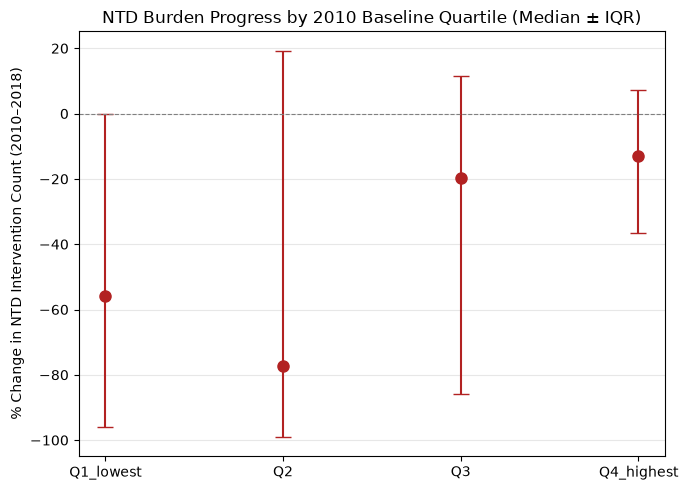

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))

x = np.arange(len(quartile_summary))
medians = quartile_summary["median"]
lower_err = medians - quartile_summary["q25"]
upper_err = quartile_summary["q75"] - medians

ax.errorbar(x, medians, yerr=[lower_err, upper_err], fmt="o", color="firebrick",
            capsize=6, markersize=8)
ax.set_xticks(x)
ax.set_xticklabels(quartile_summary.index)
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_ylabel("% Change in NTD Intervention Count (2010–2018)")
ax.set_title("NTD Burden Progress by 2010 Baseline Quartile (Median ± IQR)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
from scipy.stats import kruskal

groups = [g["pct_change"].values for _, g in q28_clean.groupby("burden_q")]
h_stat, p_val = kruskal(*groups)

print(f"Kruskal-Wallis H = {h_stat:.3f}, p = {p_val:.4f}")

Kruskal-Wallis H = 9.114, p = 0.0278


In [9]:
from scipy.stats import spearmanr

mask = np.isfinite(q28_clean["count_2010"]) & np.isfinite(q28_clean["pct_change"])
rho, p_val = spearmanr(q28_clean.loc[mask, "count_2010"], q28_clean.loc[mask, "pct_change"])

print(f"Spearman rho = {rho:.3f}, p = {p_val:.4f}")
print("(Negative rho would mean larger 2010 burden → less negative/more positive pct_change, i.e. slower progress)")

Spearman rho = 0.214, p = 0.0039
(Negative rho would mean larger 2010 burden → less negative/more positive pct_change, i.e. slower progress)


In [10]:
for q in ["Q1_lowest", "Q2", "Q3", "Q4_highest"]:
    sub = q28_clean[q28_clean["burden_q"] == q].sort_values("pct_change")
    print(f"\n--- {q} (n={len(sub)}) ---")
    print("Fastest improvers (most negative pct_change):")
    print(sub.head(3)[["country", "count_2010", "count_2018", "pct_change"]])
    print("Worst performers (highest pct_change):")
    print(sub.tail(3)[["country", "count_2010", "count_2018", "pct_change"]])


--- Q1_lowest (n=36) ---
Fastest improvers (most negative pct_change):
                  country  count_2010  count_2018  pct_change
100            Luxembourg         3.0         0.0      -100.0
180               Ukraine         4.0         0.0      -100.0
181  United Arab Emirates        10.0         0.0      -100.0
Worst performers (highest pct_change):
        country  count_2010  count_2018  pct_change
88   Kazakhstan         8.0        40.0       400.0
113    Mongolia        25.0      1810.0      7140.0
173       Tonga        30.0     37131.0    123670.0

--- Q2 (n=48) ---
Fastest improvers (most negative pct_change):
        country  count_2010  count_2018  pct_change
152      Serbia     93886.0         0.0 -100.000000
114  Montenegro      6309.0         0.0 -100.000000
109   Mauritius     24322.0         1.0  -99.995888
Worst performers (highest pct_change):
                  country  count_2010  count_2018     pct_change
5     Antigua and Barbuda       134.0      1201.0     79